In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

In [3]:
torch.cuda.is_available()

True

In [4]:
# Implementing all llm architecture
@dataclass
class GPTConfig:
    # architecture
    n_layers: int = 4
    n_heads: int = 4
    embed_dim: int = 64
    context_length: int = 128
    vocab_size: int = 50257
    # bias / preojection choices
    qkv_bias: bool = False
    proj_bias: bool = True 

    # regularization
    dropout: float = 0.2
    attn_dropout: float = 0.2
    resid_dropout: float = 0.2

    # normalization / activation
    norm_eps: float = 1e-5
    activation: str = "gelu"  # or "swiglu", "relu", etc.
    # embedding behavior
    tie_word_embeddings: bool = True
    tokenizer_name: str = "gpt2"

    def __post_init__(self):
        assert self.embed_dim % self.n_heads == 0, f"embed_dim ({self.embed_dim}) must be divisible by n_heads ({self.n_heads})"

    @property
    def head_dim(self) -> int:
        return self.embed_dim // self.n_heads

GPTConfig()

GPTConfig(n_layers=4, n_heads=4, embed_dim=64, context_length=128, vocab_size=50257, qkv_bias=False, proj_bias=True, dropout=0.2, attn_dropout=0.2, resid_dropout=0.2, norm_eps=1e-05, activation='gelu', tie_word_embeddings=True, tokenizer_name='gpt2')

#### Building tokenizer, and training llm on the TinyStories datasets

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
from datasets import load_dataset
from tokenizers import Tokenizer, pre_tokenizers, decoders
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 512
BATCH_SIZE = 16
VOCAB_SIZE = 8000

# 1. Load data
dataset = load_dataset("roneneldan/TinyStories")

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

In [12]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

ids = tokenizer.encode(dataset['train'][0]['text'])
print(ids)
print(tokenizer.decode(ids))

[3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598, 287, 607, 2119, 13, 1375, 2993, 340, 373, 2408, 284, 711, 351, 340, 780, 340, 373, 7786, 13, 20037, 2227, 284, 2648, 262, 17598, 351, 607, 1995, 11, 523, 673, 714, 34249, 257, 4936, 319, 607, 10147, 13, 198, 198, 43, 813, 1816, 284, 607, 1995, 290, 531, 11, 366, 29252, 11, 314, 1043, 428, 17598, 13, 1680, 345, 2648, 340, 351, 502, 290, 34249, 616, 10147, 1701, 2332, 1995, 13541, 290, 531, 11, 366, 5297, 11, 20037, 11, 356, 460, 2648, 262, 17598, 290, 4259, 534, 10147, 526, 198, 198, 41631, 11, 484, 4888, 262, 17598, 290, 384, 19103, 262, 4936, 319, 20037, 338, 10147, 13, 632, 373, 407, 2408, 329, 606, 780, 484, 547, 7373, 290, 5742, 1123, 584, 13, 2293, 484, 5201, 11, 20037, 26280, 607, 1995, 329, 7373, 262, 17598, 290, 18682, 607, 10147, 13, 1119, 1111, 2936, 3772, 780, 484, 550, 4888, 290, 3111, 1978, 13]
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it w

In [13]:
 
# 2. Train a custom BPE tokenizer on it
tokenizer = Tokenizer(BPE(unk_token=None))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()
 
trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=["<|endoftext|>", "<pad>"],
)
 
def batch_iterator(data, batch_size=1000):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]["text"]
 
tokenizer.train_from_iterator(batch_iterator(dataset["train"]), trainer=trainer)
eot_id = tokenizer.token_to_id("<|endoftext|>")
 
 
# 3. Split into train/val
def split_data(dataset):
    train_texts = dataset["train"]["text"]
    val_texts = dataset["validation"]["text"]
    return train_texts, val_texts
 
train_texts, val_texts = split_data(dataset)
train_texts

Column(['One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.', 'Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.\n\nOne day, Beep was driving in the park when he saw a big tree. The tree had many leaves t

In [14]:
print(type(train_texts))        # <class 'list'>
print(len(train_texts))         # number of stories
print(type(train_texts[0]))     # <class 'str'>
print(train_texts[0][:100])     # first 100 characters of the first story

<class 'datasets.arrow_dataset.Column'>
2119719
<class 'str'>
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with


In [15]:
tokenizer.encode_batch(train_texts[0:2])

[Encoding(num_tokens=160, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=174, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])]

In [18]:
encoding = tokenizer.encode("Once Upon a time")
print(encoding)          # this is the Encoding object itself
print(encoding.ids)      # the actual list of token ids
print(encoding.tokens)   # the token strings

decoded = tokenizer.decode(encoding.ids)
print(decoded)

Encoding(num_tokens=5, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
[327, 7519, 199, 155, 292]
['Once', 'ĠUp', 'on', 'Ġa', 'Ġtime']
Once Upon a time


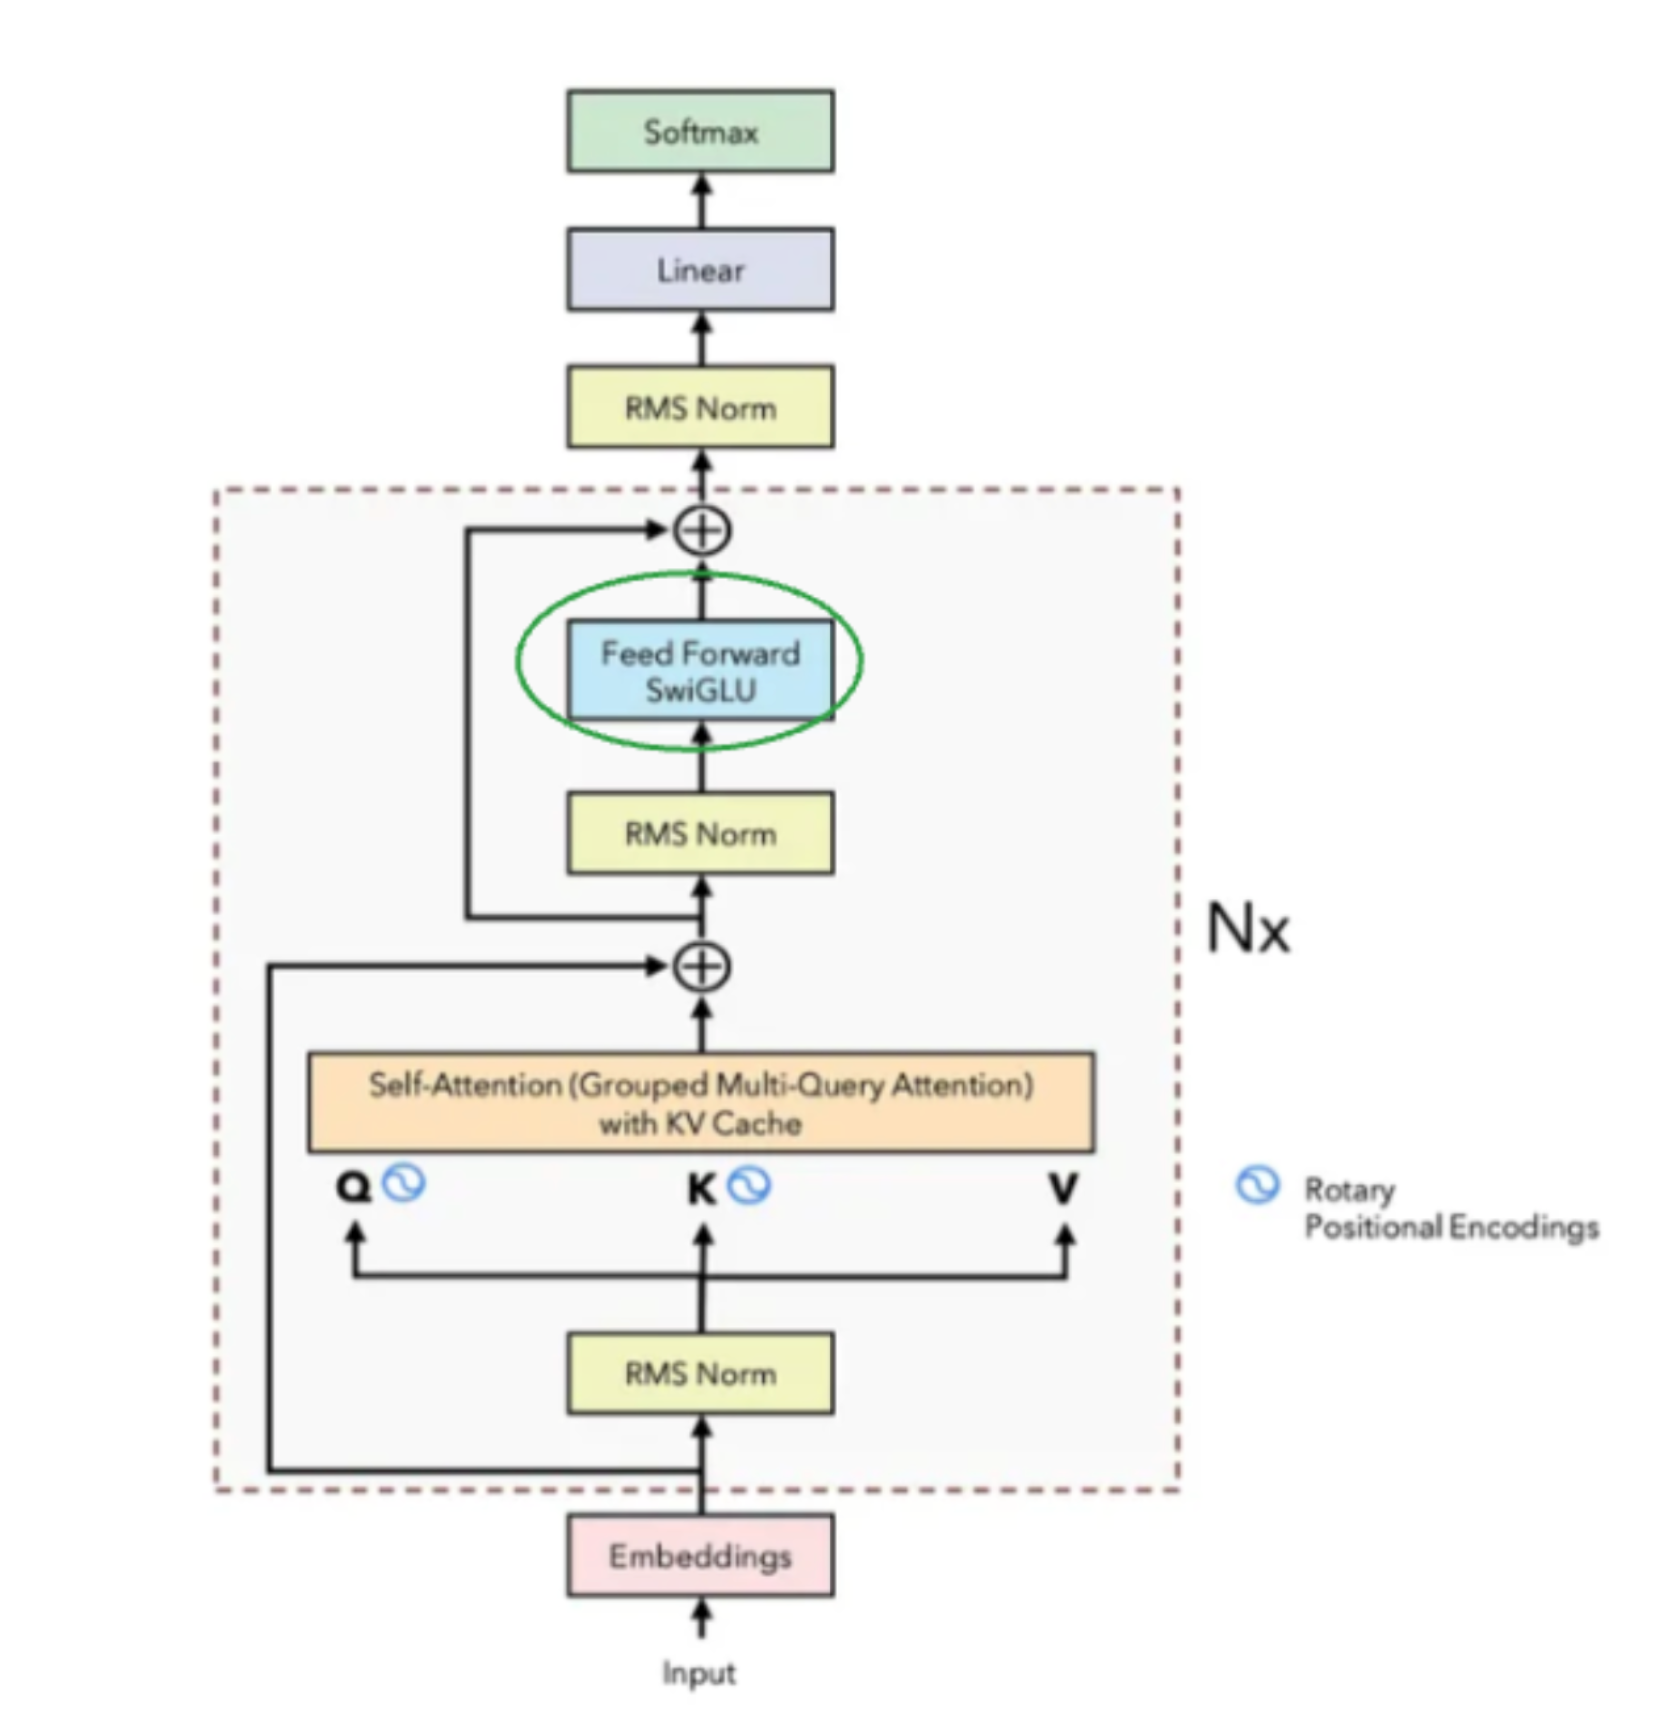

In [ ]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed (non-learned) sinusoidal positional encoding, as in
    'Attention Is All You Need'. Unlike nn.Embedding-based positional
    embeddings, this has no trainable parameters.
    """
    def __init__(self, config: GPTConfig):
        super().__init__()
        max_len = config.context_length
        d_model = config.embed_dim

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # [max_len, 1]
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )  # [d_model/2]

        pe[:, 0::2] = torch.sin(position * div_term)  # even dims
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dims

        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, d_model], not trainable

    def forward(self, x):
        # x: [B, T, d_model]
        T = x.size(1)
        return x + self.pe[:, :T, :]

class RoPe(nn.Module):
    ...


class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embed_dim, 4 * config.embed_dim, bias=config.proj_bias),
            nn.GELU(),
            nn.Linear(4 * config.embed_dim, config.embed_dim, bias=config.proj_bias),
            nn.Dropout(config.dropout)
        )

    def forward(self, x):
        x = self.net(x)
        return x

class SwiGLU(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff, bias=False)
        self.w2 = nn.Linear(d_model, d_ff, bias=False)
        self.w3 = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x):
        return self.w3(F.silu(self.w1(x)) * self.w2(x))

class RMSNorm(nn.Module):
    """
    RMSNorm: normalizes by root-mean-square only (no mean subtraction),
    and typically has no learnable shift (bias) term — used in LLaMA, etc.
    """
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.eps = config.norm_eps
        self.scale = nn.Parameter(torch.ones(config.embed_dim))

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        norm_x = x / rms 
        return self.scale * norm_x

class LayerNorm(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.eps = config.norm_eps
        self.scale = nn.Parameter(torch.ones(config.embed_dim))
        self.shift = nn.Parameter(torch.zeros(config.embed_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

## use this and check difference nn.LayerNorm()